# Topic Modeling: LDA and BERTopic
Welcome to the topic modeling notebook! Since you're new to Natural Language Processing (NLP), we'll walk through this step-by-step. 

**Topic Modeling** is a technique used to discover hidden themes (topics) in large amounts of text data. You can think of it as automatically grouping documents into categories based on the words they contain.

In this notebook, we'll explore two popular topic modeling techniques on the Thai Constitution dataset:
1. **LDA (Latent Dirichlet Allocation):** A traditional, statistical approach.
2. **BERTopic:** A modern, deep-learning approach that understands the *context* of words.


In [60]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# Setup Thai font to fix "dump" characters and boxes in plots
font_path = '../../static/font/LINESeedSansTH_Rg.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
print(f"Font loaded: {font_prop.get_name()}")


Font loaded: LINE Seed Sans TH


In [61]:
# Install required libraries 
# (We removed pyLDAvis since it has installation issues on some Mac architectures. We use matplotlib instead)
%pip install pandas numpy scikit-learn pythainlp bertopic sentence-transformers matplotlib

Note: you may need to restart the kernel to use updated packages.


In [62]:
import pandas as pd
import ast
import warnings
warnings.filterwarnings('ignore')

# We will need these later
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer


## 1. Data Loading and Preparation
First, let's load the cleaned dataset. The text has already been tokenized (split into individual words), which is perfect for traditional models like LDA.

In [63]:
# Load the dataset
df = pd.read_csv('../../data/preprocessed_data.csv')

# Safely convert tokens back to list
df['tokens'] = df['tokens'].apply(ast.literal_eval)

# Join tokens to form a single string per document
df['joined_tokens'] = df['tokens'].apply(lambda x: ' '.join(x))

display(df[['constitution_id', 'text', 'joined_tokens']].head())


,constitution_id,text,joined_tokens
0,const_2475,สยามประเทศเป็นราชอาณาจักรอันหนึ่งอันเดียว จะแบ...,สยาม ประเทศ ราชอาณาจักร แบ่งแยก ประชาชน สยาม ก...
1,const_2475,อำนาจอธิปไตยย่อมมาจากปวงชนชาวสยาม พระมหากษัตริ...,อำนาจ อธิปไตย ปวง ชน สยาม พระมหากษัตริย์ ประมุ...
2,const_2475,องค์พระมหากษัตริย์ดำรงอยู่ในฐานะอันเป็นที่เคาร...,องค์ พระมหากษัตริย์ ดำรง ฐานะ เคารพ สัก ใด ละเมิด
3,const_2475,พระมหากษัตริย์ต้องทรงเป็นพุทธมามกะ และทรงเป็นอ...,พระมหากษัตริย์ พุทธมามกะ อัครศาสนูปถัมภก
4,const_2475,พระมหากษัตริย์ทรงดำรงตำแหน่งจอมทัพ สยาม,พระมหากษัตริย์ ดำรง ตำแหน่ง จอมทัพ สยาม


In [64]:
# Define Custom Thai Legal Stopwords
from pythainlp.corpus import thai_stopwords
import pandas as pd

# Start with standard Thai stopwords
base_stopwords = list(thai_stopwords())

# Add legal-specific words that appear frequently but don't define topics
legal_noise = [
    "มาตรา", "ฉบับ", "พ.ศ.", "แห่ง", "ตาม", "นายกรัฐมนตรี", 
    "รัฐมนตรี", "สภา", "สมาชิก", "พระมหากษัตริย์", "อำนาจ",
    "บัญญัติ", "รักษา", "ประกาศ", "ระเบียบ", "ภายใต้", "กรณี"
]

custom_stopwords = list(set(base_stopwords + legal_noise))
print(f"Total stopwords: {len(custom_stopwords)}")


Total stopwords: 1044


## 2. Topic Modeling with LDA
**Latent Dirichlet Allocation (LDA)** is a classic method. It assumes:
* Every document is a mix of topics.
* Every topic is a mix of words.

To use LDA, we first need to count the words using a `CountVectorizer`. It creates a "Document-Term Matrix" (a big table of word counts).

In [65]:
# 2.1 Vectorize the text using List of Tokens (Friend's Style)
from sklearn.feature_extraction.text import CountVectorizer

# Following the EDA style: using the raw list of tokens
# We use tokenizer=lambda x: x because data is already a list of words
vectorizer = CountVectorizer(
    tokenizer=lambda x: x,
    token_pattern=None,
    lowercase=False,
    min_df=5, 
    max_df=0.9, 
    stop_words=custom_stopwords
)
X = vectorizer.fit_transform(df['tokens'])

# 2.2 Train the LDA Model
num_topics_lda = 5
lda_model = LatentDirichletAllocation(n_components=num_topics_lda, random_state=42)

print("Training LDA model...")
lda_model.fit(X)
print("Done!")


Training LDA model...
Done!


### Visualizing LDA Topics
We can look at the top words weight for each topic to understand what it's about.

Plotting top 10 words per topic in LDA:


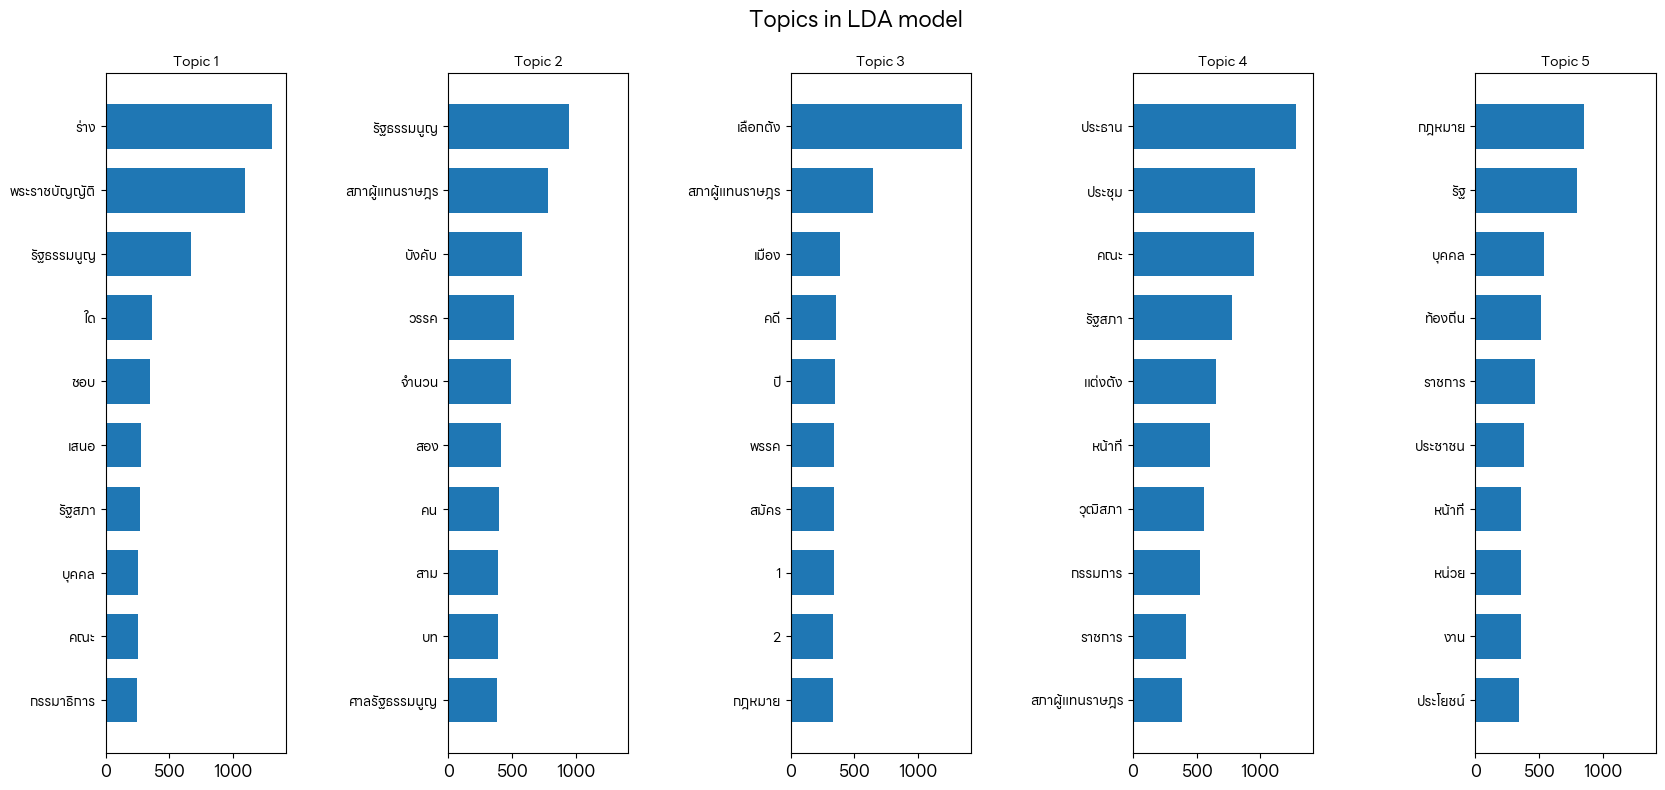

In [66]:
# Function to plot top words using matplotlib
def plot_top_words(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(1, 5, figsize=(20, 8), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 14}, fontproperties=font_prop)
        ax.invert_yaxis()
        ax.tick_params(axis="both", which="major", labelsize=12)
        
        # Use the custom Thai font for the labels
        for label in ax.get_yticklabels():
            label.set_fontproperties(font_prop)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.suptitle(title, fontsize=16, fontproperties=font_prop)
    plt.show()

print("Plotting top 10 words per topic in LDA:")
plot_top_words(lda_model, vectorizer.get_feature_names_out(), 10, "Topics in LDA model")


## 3. Topic Modeling with BERTopic
**BERTopic** is a newer model that uses deep learning (**Sentence Transformers**) to understand semantic meaning.

In [67]:
# 3.1 Setup BERTopic with Stronger Model and Fixed Data Type
from sklearn.feature_extraction.text import CountVectorizer

# 1. Use raw text for semantic meaning
docs_for_embeddings = df['text'].tolist()

# 2. Join tokens with spaces to satisfy BERTopic's string requirement
# This ensures words are counted correctly without the 'dump' character issue
docs_for_ctfidf = df['tokens'].apply(lambda x: ' '.join(x)).tolist()

# 3. Upgrade to the more powerful 'mpnet' model for better Thai understanding
print("Generating embeddings... (using multilingual-MPNet-base-v2)")
embedding_model = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")
embeddings = embedding_model.encode(docs_for_embeddings, show_progress_bar=True)

# 4. Vectorizer: Since words are now space-separated, we use a Thai-safe pattern
vectorizer_model = CountVectorizer(
    token_pattern=r"[\u0e00-\u0e7f]+",
    lowercase=False,
    stop_words=custom_stopwords
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    verbose=True
)

print("Training BERTopic...")
topics, probs = topic_model.fit_transform(docs_for_ctfidf, embeddings=embeddings)
print("Done!")


Generating embeddings... (using multilingual-MPNet-base-v2)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10387.75it/s]
XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 148/148 [00:52<00:00,  2.82it/s]
2026-04-20 17:04:23,425 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Training BERTopic...


2026-04-20 17:04:25,119 - BERTopic - Dimensionality - Completed ✓
2026-04-20 17:04:25,120 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-20 17:04:25,278 - BERTopic - Cluster - Completed ✓
2026-04-20 17:04:25,282 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-20 17:04:25,359 - BERTopic - Representation - Completed ✓


Done!


In [68]:
# Let's look at the topics found by BERTopic
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))


,Topic,Count,Name,Representation,Representative_Docs
0,-1,831,-1_ร่าง_รัฐธรรมนูญ_ชาติ_พระราชบัญญัติ,"[ร่าง, รัฐธรรมนูญ, ชาติ, พระราชบัญญัติ, กรรมกา...",[เสนอ สภานิติบัญญัติแห่งชาติ คณะ รัฐมนตรี คณะ ...
1,0,65,0_บังคับ_คุ้มกัน__,"[บังคับ, คุ้มกัน, , , , , , , , ]","[บังคับ, บังคับ, บังคับ]"
2,1,59,1_ข้อ_ประชุม_รัฐสภา_อนุโลม,"[ข้อ, ประชุม, รัฐสภา, อนุโลม, บังคับ, ยุบ, พลา...",[ประชุม รัฐสภา ข้อ บังคับ ประชุม รัฐสภา ข้อ บั...
3,2,56,2_ว่าง_อายุ_แทน_สลาก,"[ว่าง, อายุ, แทน, สลาก, สมาชิกภาพ, ร้อยแปด, ตำ...",[ตำแหน่ง สมาชิก สภาผู้แทนราษฎร ว่าง ใด อายุ สภ...
4,3,51,3_เลือกตั้ง_คณะกรรมการการเลือกตั้ง_ออกเสียง_ปร...,"[เลือกตั้ง, คณะกรรมการการเลือกตั้ง, ออกเสียง, ...",[วรรค สอง 4 สั่ง เลือกตั้ง ออกเสียง ประชามติ ห...
5,4,49,4_ราชอาณาจักรไทย_พุทธศักราช_รัฐธรรมนูญ_ชั่วคราว,"[ราชอาณาจักรไทย, พุทธศักราช, รัฐธรรมนูญ, ชั่วค...",[1 ดําเนิน แต่งตั้ง รัฐมนตรี เวลา วรรค ดําเนิน...
6,5,47,5_คุมขัง_เสรีภาพ_ค้น_ตัว,"[คุมขัง, เสรีภาพ, ค้น, ตัว, จับกุม, สิทธิ, บุค...",[บุคคล เสรีภาพ บริบูรณ์ ร่างกาย จับกุม คุมขัง ...
7,6,44,6_หุ้นส่วน_บริษัท_ห้าง_หุ้น,"[หุ้นส่วน, บริษัท, ห้าง, หุ้น, กำไร, ห้าม, ธุร...",[นายก รัฐมนตรี รัฐมนตรี หุ้นส่วน หุ้น ห้าง หุ้...
8,7,44,7_ตุลาการ_สิบ_หมาย_สาม,"[ตุลาการ, สิบ, หมาย, สาม, แต่งตั้ง, รัฐธรรมนูญ...",[เลือกตั้ง ทั่วไป รัฐสภา แต่งตั้ง ตุลาการ รัฐธ...
9,8,43,8_สมัคร_เขต_บัญชี_เลือกตั้ง,"[สมัคร, เขต, บัญชี, เลือกตั้ง, พรรค, แบ่ง, ชื่...",[เลือกตั้ง สมาชิก สภาผู้แทนราษฎร สัดส่วน เลือก...


In [69]:
# Visualize the top words per topic as a bar chart (BERTopic natively supports Plotly)
fig = topic_model.visualize_barchart(top_n_topics=8)
fig


In [70]:
# Visualize the distance between topics
fig2 = topic_model.visualize_topics()
fig2


In [71]:
# 4. Advanced BERTopic Visualizations
# Visualize the hierarchical structure of topics
hierarchical_topics = topic_model.hierarchical_topics(docs)
fig_hierarchy = topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)
fig_hierarchy.show()

# Visualize Topic Heatmap (Similarity Matrix)
fig_heatmap = topic_model.visualize_heatmap()
fig_heatmap.show()


100%|██████████| 188/188 [00:00<00:00, 1070.55it/s]
